# Exercício - Análise Gráfica Covid-19

#### A Covid-19, causada pelo coronavírus SARS-CoV-2, foi declarada pandemia pela Organização Mundial da Saúde (OMS) em março de 2020. A doença se espalhou rapidamente pelo mundo, resultando em milhões de infecções e mortes, além de impactos sociais e econômicos profundos.


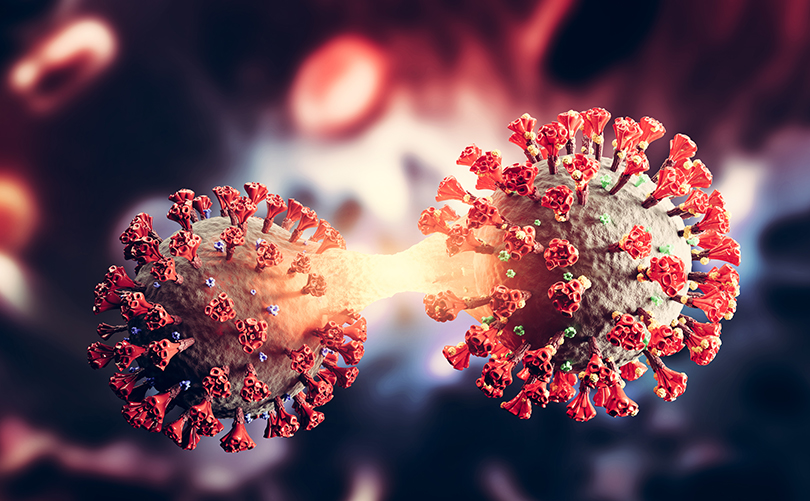


### Países mais afetados

#### Os países mais afetados variaram ao longo da pandemia, mas alguns dos que registraram os maiores números de casos e mortes foram:
- Estados Unidos: O país teve o maior número de casos e óbitos, com picos severos em diferentes ondas da pandemia.
- Índia: Enfrentou um grande surto em 2021, especialmente devido à variante Delta.
- Brasil: Um dos epicentros da pandemia na América Latina, com altos índices de infecção e hospitalização.
- Rússia e México: Também tiveram taxas elevadas de infecção e óbitos.
- Países europeus (Reino Unido, França, Itália e Espanha): Foram gravemente afetados nas primeiras ondas e tiveram impactos significativos nos sistemas de saúde.

#### As respostas dos governos e a capacidade dos sistemas de saúde influenciaram a severidade da pandemia em cada local.

### Estratégias para lidar com a pandemia

#### Os países adotaram diferentes estratégias para conter a disseminação do vírus, incluindo:
- Distanciamento social e lockdowns: Muitos governos impuseram restrições à circulação de pessoas, fechamento de comércios e trabalho remoto para reduzir a transmissão.
- Uso de máscaras: O uso de máscaras faciais foi incentivado (e, em alguns locais, obrigatório) para diminuir a propagação do vírus.
- Testagem em massa e rastreamento de contatos: Países como Coreia do Sul e Alemanha implementaram testes amplos e rastreamento de contatos para isolar casos positivos rapidamente.
- Vacinação em larga escala: O desenvolvimento e distribuição de vacinas foram essenciais para reduzir os casos graves e óbitos.

### Testes e diagnóstico

#### Os testes para Covid-19 foram cruciais no combate à pandemia. Os principais tipos incluíam:
- RT-PCR: Considerado o mais confiável, detecta o material genético do vírus e confirma infecções ativas.
- Testes rápidos de antígeno: Mais baratos e rápidos, detectam proteínas do vírus, mas são menos sensíveis.
- Testes sorológicos: Identificam a presença de anticorpos no sangue, indicando se a pessoa já teve contato com o vírus no passado.

#### A testagem em larga escala ajudou a monitorar a propagação da doença e a tomar decisões sobre restrições e medidas de saúde pública.

### Vacinas e imunização

#### O desenvolvimento de vacinas para Covid-19 foi um dos processos mais rápidos da história da medicina. Algumas das principais vacinas aprovadas foram:
- Pfizer-BioNTech (mRNA)
- Moderna (mRNA)
- AstraZeneca-Oxford (vetor viral)
- Janssen/Johnson & Johnson (vetor viral)
- Sinovac-Coronavac e Sinopharm (vírus inativado)
- Sputnik V (vetor viral, Rússia)

#### As vacinas reduziram significativamente os casos graves e óbitos, permitindo a reabertura gradual das economias e o retorno à normalidade em muitas regiões.

<hr>

### Dados

#### O dataset que será trabalhado foi obtido no [Kaggle](https://www.kaggle.com/datasets/themrityunjaypathak/covid-cases-and-deaths-worldwide) e contem as seguintes características:

- **Formato**: CSV
- **Arquivo**: covid_worldwide.csv
- **Colunas**:
    - Serial Number: Serial Number of Country
    - Country: Name of the Country
    - Total Cases: Total Cases in the Following Country
    - Total Deaths: otal Deaths in the Following Country
    - Total Recovered: Total Recovered in the Following Country
    - Active Cases: Total Active Cases in the Following Country
    - Total Test: Total Covid Test in the Following Country
    - Population: Population of the Following Country



### Objetivo

#### Criar visualizações gráficas para identificar padrões e tendências nos dados de COVID-19 em diferentes países.

1. **Distribuição de Casos e Mortes**: Há países com muitos casos, mas poucas mortes?
2. **Relação Entre Casos e Mortes**: Existe uma correlação entre casos e mortes?
3. **Casos Ativos vs. População**: Países mais populosos possuem mais casos ativos?
4. **Países com Mais Casos e Mortes**:Quais países lideram em número de casos e mortes?
5. **Proporção de Recuperação**: A taxa de recuperação é homogênea entre os países?
6. **Testagem vs. População**: Países mais populosos realizam mais testes?
7. **Correlações**: Quais variáveis apresentam maior correlação?

### Análises Adicionais

1.	📊 Comparação de Taxas de Mortalidade e Recuperação
	- Calcule e visualize a taxa de mortalidade (Total Deaths / Total Cases) e a taxa de recuperação (Total Recovered / Total Cases).
	- 🔍 Insight: Existem países com taxas de recuperação muito diferentes? Algum país tem uma taxa de mortalidade anormalmente alta?
2.	🌎 Mapa Geoespacial de Casos (Se houver coordenadas)
	- Crie um mapa mundial destacando os países mais afetados.
	- 🔍 Insight: Os continentes ou regiões específicas tiveram um impacto maior da pandemia?
3.	📉 Impacto do Número de Testes nos Casos Confirmados
	- Verifique a relação entre Total Tests e Total Cases.
	- 🔍 Insight: Países que testaram mais detectaram mais casos? O número de testes influencia diretamente os casos confirmados?
4.	📊 Variabilidade de Casos por Região
	- Se houver agrupamento por continente ou região compare a variação dos casos.
	- 🔍 Insight: Existem continentes com mais outliers? Algum tem uma variação muito maior nos casos?
5.	📉 Tendência de Casos Ativos por População
	- Analise se países com maior população também tiveram mais casos ativos proporcionalmente.
	- 🔍 Insight: Países populosos sempre tiveram mais casos ou a distribuição é desigual?

In [1]:
!pip install pycountry pycountry-convert
!pip install geopandas pycountry
!pip install mapclassify

In [2]:
#Bibliotecas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pycountry_convert as pc
import plotly.express as px
import folium
import geopandas as gpd
import pycountry
from geopandas import GeoDataFrame
import mapclassify
import numpy as np
from scipy.stats import linregress
from scipy.stats import pearsonr

In [3]:
# Mostrar os dados do dataframe
df = pd.read_csv('/content/covid_worldwide.csv')
df.head()

,Serial Number,Country,Total Cases,Total Deaths,Total Recovered,Active Cases,Total Test,Population
0,1,USA,"104,196,861","1,132,935","101,322,779","1,741,147","1,159,832,679","334,805,269"
1,2,India,"44,682,784","530,740","44,150,289","1,755","915,265,788","1,406,631,776"
2,3,France,"39,524,311","164,233","39,264,546","95,532","271,490,188","65,584,518"
3,4,Germany,"37,779,833","165,711","37,398,100","216,022","122,332,384","83,883,596"
4,5,Brazil,"36,824,580","697,074","35,919,372","208,134","63,776,166","215,353,593"


In [4]:
#Retirar a colunar Serial Number
#df = df.drop('Serial Number',axis=1)
df.head()

,Serial Number,Country,Total Cases,Total Deaths,Total Recovered,Active Cases,Total Test,Population
0,1,USA,"104,196,861","1,132,935","101,322,779","1,741,147","1,159,832,679","334,805,269"
1,2,India,"44,682,784","530,740","44,150,289","1,755","915,265,788","1,406,631,776"
2,3,France,"39,524,311","164,233","39,264,546","95,532","271,490,188","65,584,518"
3,4,Germany,"37,779,833","165,711","37,398,100","216,022","122,332,384","83,883,596"
4,5,Brazil,"36,824,580","697,074","35,919,372","208,134","63,776,166","215,353,593"


In [5]:
#Verificar as informações do CSV, se existe dados nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 231 entries, 0 to 230
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Serial Number    231 non-null    int64 
 1   Country          231 non-null    object
 2   Total Cases      231 non-null    object
 3   Total Deaths     225 non-null    object
 4   Total Recovered  210 non-null    object
 5   Active Cases     212 non-null    object
 6   Total Test       213 non-null    object
 7   Population       228 non-null    object
dtypes: int64(1), object(7)
memory usage: 14.6+ KB


In [6]:
# Verificar se tem valores NaN
df.isna().sum()

,0
Serial Number,0
Country,0
Total Cases,0
Total Deaths,6
Total Recovered,21
Active Cases,19
Total Test,18
Population,3


In [7]:
#Verifica os tipos de dados de cada coluna
df.dtypes

,0
Serial Number,int64
Country,object
Total Cases,object
Total Deaths,object
Total Recovered,object
Active Cases,object
Total Test,object
Population,object


In [8]:
# Filtrar e mostrar apenas as linhas que possuem valores NaN
df_nan = df[df.isna().any(axis=1)]
print(df_nan)

     Serial Number                 Country Total Cases Total Deaths  \
10              11                  Turkey  17,042,722      101,492   
29              30                    DPRK   4,772,813           74   
65              66                 Tunisia   1,150,356       29,308   
77              78                Paraguay     806,256       19,820   
90              91                   China     503,302        5,272   
94              95                Honduras     470,757       11,104   
111            112              Martinique     229,687        1,097   
112            113                    Laos     217,973          758   
113            114                 Iceland     208,688          229   
117            118              Guadeloupe     201,394        1,007   
136            137                Suriname      82,020        1,398   
138            139        French Polynesia      77,957          649   
150            151              Seychelles      50,665          172   
156   

In [9]:
#Converter colunas para valores numéricos
df['Total Deaths'] = df['Total Deaths'].astype(str).str.replace(',', '').astype(float)
df['Total Cases'] = df['Total Cases'].astype(str).str.replace(',', '').astype(float)
df['Total Recovered'] = df['Total Recovered'].astype(str).str.replace(',', '').astype(float)
df['Active Cases'] = df['Active Cases'].astype(str).str.replace(',', '').astype(float)
df['Total Test'] = df['Total Test'].astype(str).str.replace(',', '').astype(float)
df['Population'] = df['Population'].astype(str).str.replace(',', '').astype(float)

In [10]:
# Mostra os tipos de dados das colunas
print(df.dtypes)

Serial Number        int64
Country             object
Total Cases        float64
Total Deaths       float64
Total Recovered    float64
Active Cases       float64
Total Test         float64
Population         float64
dtype: object


In [11]:
# Preencher valores numéricos com a mediana da respectiva coluna
for col in df.select_dtypes(include=['float64', 'int64']).columns:
    df[col].fillna(df[col].median(), inplace=True)

# Verificar novamente se há valores ausentes
print(df.isna().sum())

Serial Number      0
Country            0
Total Cases        0
Total Deaths       0
Total Recovered    0
Active Cases       0
Total Test         0
Population         0
dtype: int64


<ipython-input-11-1493ad4d0e4d>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


1.	📊 Comparação de Taxas de Mortalidade e Recuperação
	- Calcule e visualize a taxa de mortalidade (Total Deaths / Total Cases) e a taxa de recuperação (Total Recovered / Total Cases).
	- 🔍 Insight: Existem países com taxas de recuperação muito diferentes? Algum país tem uma taxa de mortalidade anormalmente alta?
2.	🌎 Mapa Geoespacial de Casos (Se houver coordenadas)
	- Crie um mapa mundial destacando os países mais afetados.
	- 🔍 Insight: Os continentes ou regiões específicas tiveram um impacto maior da pandemia?
3.	📉 Impacto do Número de Testes nos Casos Confirmados
	- Verifique a relação entre Total Tests e Total Cases.
	- 🔍 Insight: Países que testaram mais detectaram mais casos? O número de testes influencia diretamente os casos confirmados?
4.	📊 Variabilidade de Casos por Região
	- Se houver agrupamento por continente ou região compare a variação dos casos.
	- 🔍 Insight: Existem continentes com mais outliers? Algum tem uma variação muito maior nos casos?
5.	📉 Tendência de Casos Ativos por População
	- Analise se países com maior população também tiveram mais casos ativos proporcionalmente.
	- 🔍 Insight: Países populosos sempre tiveram mais casos ou a distribuição é desigual?

1.	📊 Comparação de Taxas de Mortalidade e Recuperação
	- Calcule e visualize a taxa de mortalidade (Total Deaths / Total Cases) e a taxa de recuperação (Total Recovered / Total Cases).
	- 🔍 Insight: Existem países com taxas de recuperação muito diferentes? Algum país tem uma taxa de mortalidade anormalmente alta?
  R: **Países como:**
                  Tokelau           Oceania
                  Vatican City      Desconhecido
                  Niue              Oceania
                  Falkland Islands  América do Sul
                  Saint Helena      Desconhecido
                  Tuvalu            Oceania
                  MS Zaandam        Desconhecido
                  Yemen             Ásia
                  Western Sahara    Desconhecido
                  Sudan             África
                  Syria             Ásia
                  Somalia           África
                  Peru              América do Sul
**Tiveram uma taxa de mortalidade anormalmente alta, podendo ser falta de dados ou até mesmo alguns outliers modificando a percepção do problema**   



In [12]:
# Calcular Taxa de Mortalidade (%)
df["Mortality Rate (%)"] = (df["Total Deaths"] / df["Total Cases"]) * 100

# Calcular Taxa de Recuperação (%)
df["Recovery Rate (%)"] = (df["Total Recovered"] / df["Total Cases"]) * 100

# Exibir as primeiras linhas para conferir
df[["Country", "Mortality Rate (%)", "Recovery Rate (%)"]].head()

,Country,Mortality Rate (%),Recovery Rate (%)
0,USA,1.087302,97.241681
1,India,1.187795,98.808277
2,France,0.415524,99.342772
3,Germany,0.438623,98.989585
4,Brazil,1.892958,97.541838


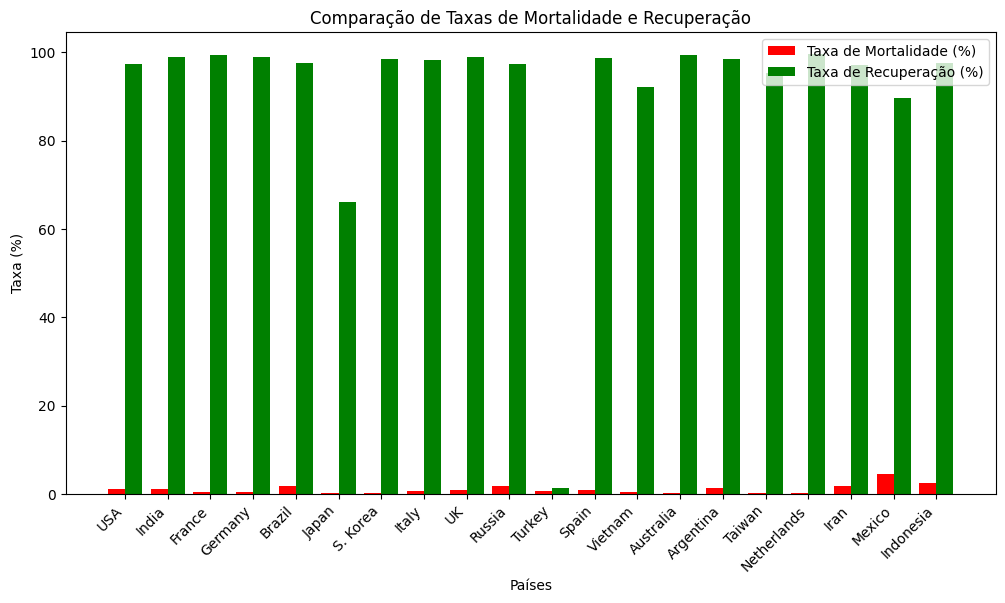

In [13]:
# Ordenar os países pelos casos totais e pegar os 20 primeiros
df_sorted = df.sort_values(by="Total Cases", ascending=False).head(20)

# Criar o gráfico de barras comparando Mortalidade e Recuperação
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(df_sorted["Country"]))  # Posições no eixo X
width = 0.4  # Largura das barras

# Barras para Mortalidade
ax.bar(x - width/2, df_sorted["Mortality Rate (%)"], width, label="Taxa de Mortalidade (%)", color="red")
# Barras para Recuperação
ax.bar(x + width/2, df_sorted["Recovery Rate (%)"], width, label="Taxa de Recuperação (%)", color="green")

# Personalizar o gráfico
ax.set_xlabel("Países")
ax.set_ylabel("Taxa (%)")
ax.set_title("Comparação de Taxas de Mortalidade e Recuperação")
ax.set_xticks(x)
ax.set_xticklabels(df_sorted["Country"], rotation=45, ha="right")
ax.legend()

# Mostrar o gráfico
plt.show()

In [14]:
# Criar uma cópia para evitar avisos de alteração no DataFrame original
df_copy = df.copy()

# Calcular a taxa de mortalidade
df_copy["Mortality Rate (%)"] = (df_copy["Total Deaths"] / df_copy["Total Cases"]) * 100

# Ordenar pelos países com maior taxa de mortalidade
df_top20_mortality = df_copy.sort_values(by="Mortality Rate (%)", ascending=False).head(20)

# Exibir os 20 países com maior taxa de mortalidade
print(df_top20_mortality[["Country", "Mortality Rate (%)"]])

                    Country  Mortality Rate (%)
230                 Tokelau        43580.000000
227            Vatican City         7513.793103
225                    Niue          291.700134
223        Falkland Islands          112.901554
222            Saint Helena          100.600185
221                  Tuvalu           77.682709
229              MS Zaandam           22.222222
196                   Yemen           18.074508
228          Western Sahara           10.000000
144                   Sudan            7.845690
148                   Syria            5.507110
170                 Somalia            4.982063
34                     Peru            4.885085
88                    Egypt            4.773245
18                   Mexico            4.508505
96   Bosnia and Herzegovina            4.049738
114             Afghanistan            3.779520
205                 Liberia            3.646738
218                   Macao            3.440367
67                  Ecuador            3

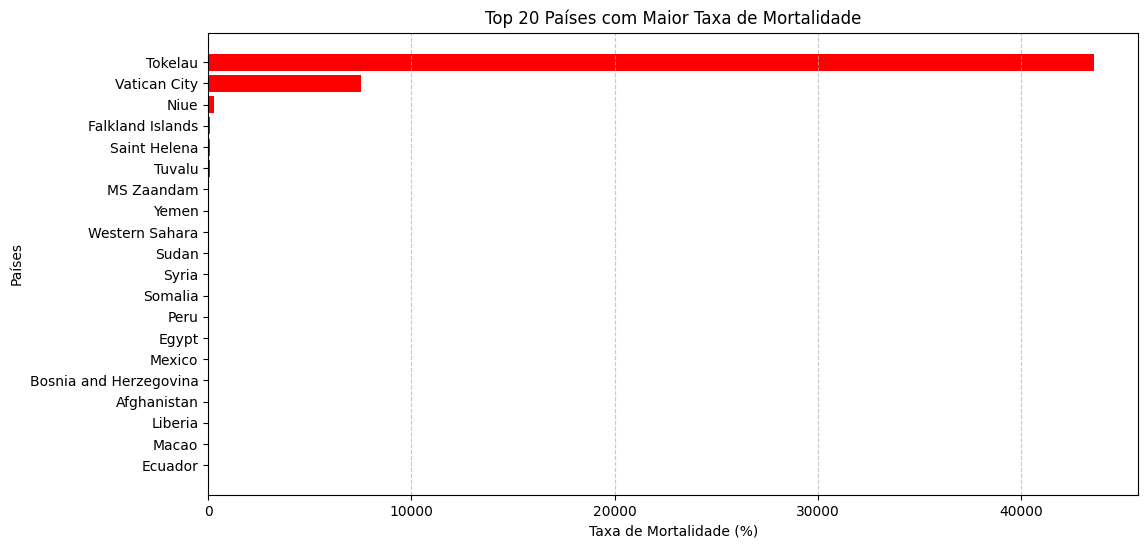

In [15]:
# Criar gráfico de barras
plt.figure(figsize=(12, 6))
plt.barh(df_top20_mortality["Country"], df_top20_mortality["Mortality Rate (%)"], color="red")
plt.xlabel("Taxa de Mortalidade (%)")
plt.ylabel("Países")
plt.title("Top 20 Países com Maior Taxa de Mortalidade")
plt.gca().invert_yaxis()  # Inverter para mostrar o maior no topo
plt.grid(axis="x", linestyle="--", alpha=0.7)

# Mostrar gráfico
plt.show()

In [16]:
# Função para obter o continente com base no nome do país
def get_continent(country):
    try:
        # Converter nome do país para código ISO Alpha-2
        country_code = pc.country_name_to_country_alpha2(country, cn_name_format="default")
        # Converter código Alpha-2 para continente
        continent_code = pc.country_alpha2_to_continent_code(country_code)
        # Mapear código do continente para nome completo
        continent_mapping = {
            "AF": "África",
            "AS": "Ásia",
            "EU": "Europa",
            "NA": "América do Norte",
            "SA": "América do Sul",
            "OC": "Oceania",
            "AN": "Antártida"
        }
        return continent_mapping.get(continent_code, "Desconhecido")
    except:
        return "Desconhecido"

# Aplicar a função na coluna 'Country' do DataFrame
df_top20_mortality["Continent"] = df_top20_mortality["Country"].apply(get_continent)

# Visualizar os primeiros resultados
print(df_top20_mortality[['Country', 'Continent']].head(20))

                    Country         Continent
230                 Tokelau           Oceania
227            Vatican City      Desconhecido
225                    Niue           Oceania
223        Falkland Islands    América do Sul
222            Saint Helena      Desconhecido
221                  Tuvalu           Oceania
229              MS Zaandam      Desconhecido
196                   Yemen              Ásia
228          Western Sahara      Desconhecido
144                   Sudan            África
148                   Syria              Ásia
170                 Somalia            África
34                     Peru    América do Sul
88                    Egypt            África
18                   Mexico  América do Norte
96   Bosnia and Herzegovina            Europa
114             Afghanistan              Ásia
205                 Liberia            África
218                   Macao              Ásia
67                  Ecuador    América do Sul


In [17]:
# Criar uma cópia para evitar avisos de alteração no DataFrame original
df_copy = df.copy()

# Calcular a taxa de recuperação e atribuir à coluna 'Recovery Rate (%)'
df_copy["Recovery Rate (%)"] = (df_copy["Total Recovered"] / df_copy["Total Cases"]) * 100

# Ordenar pelos países com maior taxa de recuperação
df_top20_recovery = df_copy.sort_values(by="Recovery Rate (%)", ascending=False).head(20)

# Exibir os 20 países com maior taxa de recuperação
print(df_top20_recovery[["Country", "Recovery Rate (%)"]])

                    Country  Recovery Rate (%)
230                 Tokelau       4.702910e+06
221                  Tuvalu       8.383084e+03
214               St. Barth       4.338478e+03
208  British Virgin Islands       3.218966e+03
206            Sierra Leone       3.030226e+03
175              Micronesia       1.036980e+03
172         Solomon Islands       9.568484e+02
164          Faeroe Islands       6.784739e+02
161             Isle of Man       6.186737e+02
157                 Mayotte       5.598436e+02
156                Tanzania       5.511567e+02
138        French Polynesia       3.016349e+02
136                Suriname       2.866929e+02
117              Guadeloupe       1.167589e+02
113                 Iceland       1.126780e+02
112                    Laos       1.078783e+02
111              Martinique       1.023765e+02
223        Falkland Islands       1.000000e+02
227            Vatican City       1.000000e+02
29                     DPRK       9.999845e+01


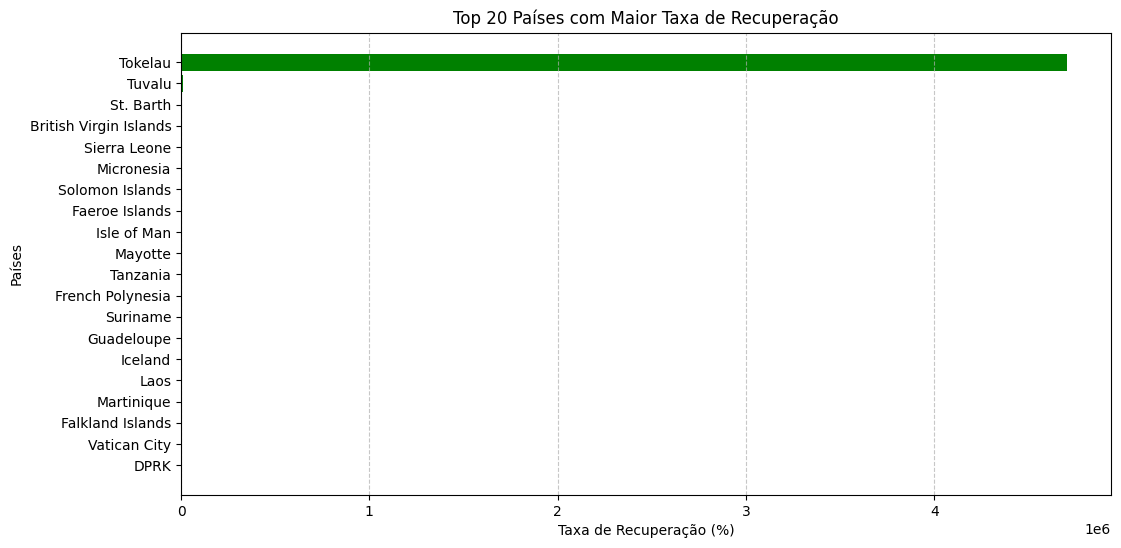

In [18]:
# Criar gráfico de barras
plt.figure(figsize=(12, 6))
plt.barh(df_top20_recovery["Country"], df_top20_recovery["Recovery Rate (%)"], color='green')
plt.xlabel("Taxa de Recuperação (%)")
plt.ylabel("Países")
plt.title("Top 20 Países com Maior Taxa de Recuperação")
plt.gca().invert_yaxis()  # Inverte a ordem para mostrar o maior primeiro
plt.grid(axis="x", linestyle="--", alpha=0.7)

plt.show()

In [19]:
# Função para obter o continente com base no nome do país
def get_continent(country):
    try:
        # Converter nome do país para código ISO Alpha-2
        country_code = pc.country_name_to_country_alpha2(country, cn_name_format="default")
        # Converter código Alpha-2 para continente
        continent_code = pc.country_alpha2_to_continent_code(country_code)
        # Mapear código do continente para nome completo
        continent_mapping = {
            "AF": "África",
            "AS": "Ásia",
            "EU": "Europa",
            "NA": "América do Norte",
            "SA": "América do Sul",
            "OC": "Oceania",
            "AN": "Antártida"
        }
        return continent_mapping.get(continent_code, "Desconhecido")
    except:
        return "Desconhecido"

# Aplicar a função na coluna 'Country' do DataFrame df_top20_recovery
df_top20_recovery["Continent"] = df_top20_recovery["Country"].apply(get_continent) # Changed from df_top20_mortality to df_top20_recovery

# Visualizar os primeiros resultados
print(df_top20_recovery[['Country', 'Continent']].head(20))

                    Country         Continent
230                 Tokelau           Oceania
221                  Tuvalu           Oceania
214               St. Barth      Desconhecido
208  British Virgin Islands  América do Norte
206            Sierra Leone            África
175              Micronesia           Oceania
172         Solomon Islands           Oceania
164          Faeroe Islands      Desconhecido
161             Isle of Man            Europa
157                 Mayotte            África
156                Tanzania            África
138        French Polynesia           Oceania
136                Suriname    América do Sul
117              Guadeloupe  América do Norte
113                 Iceland            Europa
112                    Laos              Ásia
111              Martinique  América do Norte
223        Falkland Islands    América do Sul
227            Vatican City      Desconhecido
29                     DPRK      Desconhecido


2.	🌎 Mapa Geoespacial de Casos (Se houver coordenadas)
	- Crie um mapa mundial destacando os países mais afetados.
	- 🔍 Insight: Os continentes ou regiões específicas tiveram um impacto maior da pandemia?

 **R: Continentes como America do Norte, America do Sul, Europa e Oceania tiveram impactos maiores com a pandemia**


In [20]:
# Gerenando o código país de acordo com o nome

def alpha3code(column):
    CODE=[]
    for country in column:
        try:
            code=pycountry.countries.get(name=country).alpha_3
           # .alpha_3 means 3-letter country code
            CODE.append(code)
        except:
            CODE.append(country)
    return CODE
# creando a coluna de código
df['CODE']=alpha3code(df.Country)
df.head()

,Serial Number,Country,Total Cases,Total Deaths,Total Recovered,Active Cases,Total Test,Population,Mortality Rate (%),Recovery Rate (%),CODE
0,1,USA,104196861.0,1132935.0,101322779.0,1741147.0,1.159833e+09,3.348053e+08,1.087302,97.241681,USA
1,2,India,44682784.0,530740.0,44150289.0,1755.0,9.152658e+08,1.406632e+09,1.187795,98.808277,IND
2,3,France,39524311.0,164233.0,39264546.0,95532.0,2.714902e+08,6.558452e+07,0.415524,99.342772,FRA
3,4,Germany,37779833.0,165711.0,37398100.0,216022.0,1.223324e+08,8.388360e+07,0.438623,98.989585,DEU
4,5,Brazil,36824580.0,697074.0,35919372.0,208134.0,6.377617e+07,2.153536e+08,1.892958,97.541838,BRA


In [21]:
# Caminho local do arquivo após extração
shapefile_path = "/content/ne_110m_admin_0_countries.shp"

# Ler o arquivo do Natural Earth localmente
# Try to force the shapefile to be restored by setting SHAPE_RESTORE_SHX to YES
world = gpd.read_file(shapefile_path, SHAPE_RESTORE_SHX='YES') # Add the SHAPE_RESTORE_SHX parameter

world = world.rename(columns={'POP_EST': 'pop_est', 'CONTINENT': 'continent',
                              'NAME': 'name', 'ISO_A3': 'CODE',
                              'GDP_MD_EST': 'gdp_md_est', 'geometry': 'geometry'})
df.columns = ['Serial_number', 'Country', 'Total_cases', 'Total_deaths',
              'Total_recovered', 'Active_cases', 'Total_test', 'Population',
              'Mortality_rate', 'Recovery_rate', 'CODE']
# Mesclar os dados de COVID com os dados geoespaciais
merge1 = pd.merge(df, world, on='CODE')

# Ler os dados de latitude e longitude dos países
location = pd.read_csv('https://raw.githubusercontent.com/melanieshi0120/COVID-19_global_time_series_panel_data/master/data/countries_latitude_longitude.csv')

# Mesclar com os dados de localização
merge2 = merge1.merge(location, on='name')

# Exibir algumas linhas para verificar a fusão
print(merge2.head())

/usr/local/lib/python3.11/dist-packages/pyogrio/raw.py:198: RuntimeWarning: driver ESRI Shapefile does not support open option SHAPE_RESTORE_SHX
  return ogr_read(


   Serial_number  Country  Total_cases  Total_deaths  Total_recovered  \
0              1      USA  104196861.0     1132935.0      101322779.0   
1              2    India   44682784.0      530740.0       44150289.0   
2              4  Germany   37779833.0      165711.0       37398100.0   
3              5   Brazil   36824580.0      697074.0       35919372.0   
4              6    Japan   32588442.0       68399.0       21567425.0   

   Active_cases    Total_test    Population  Mortality_rate  Recovery_rate  \
0     1741147.0  1.159833e+09  3.348053e+08        1.087302      97.241681   
1        1755.0  9.152658e+08  1.406632e+09        1.187795      98.808277   
2      216022.0  1.223324e+08  8.388360e+07        0.438623      98.989585   
3      208134.0  6.377617e+07  2.153536e+08        1.892958      97.541838   
4    10952618.0  9.214464e+07  1.255848e+08        0.209887      66.181209   

   ... FCLASS_PL FCLASS_GR  FCLASS_IT  FCLASS_NL FCLASS_SE FCLASS_BD  \
0  ...      None    

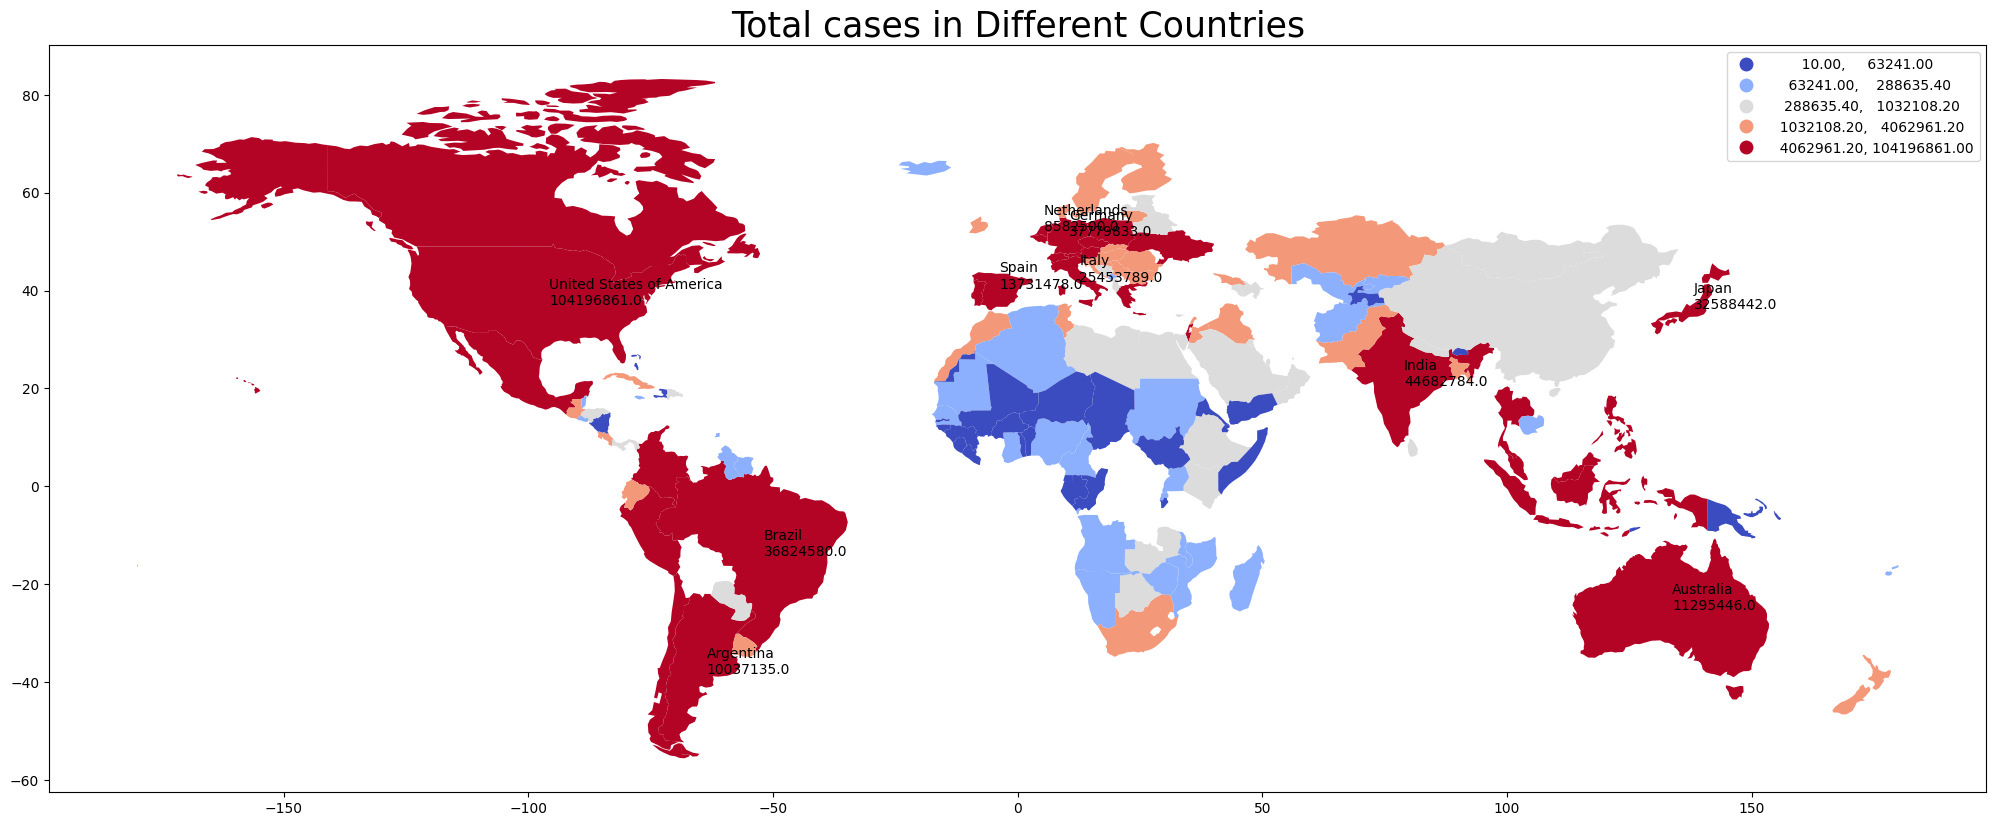

In [22]:
# Confirmando caso no mapa mundi
merge2 = GeoDataFrame(merge2)
merge2.plot(column='Total_cases', scheme="quantiles", # This line requires mapclassify
           figsize=(25, 20),
           legend=True,cmap='coolwarm')
plt.title('Total cases in Different Countries',fontsize=25)
# Adicionando nomes e casos dos países
for i in range(0,10):
    plt.text(float(merge2.longitude[i]),float(merge2.latitude[i]),"{}\n{}".format(merge2.name[i],merge2.Total_cases[i]),size=10)
plt.show()

3.	📉 Impacto do Número de Testes nos Casos Confirmados
	- Verifique a relação entre Total Tests e Total Cases.
	- 🔍 Insight: Países que testaram mais detectaram mais casos? O número de testes influencia diretamente os casos confirmados?
  R:  **coeficiente de determinação R² = 0.71 indica que 71% da variação no número de casos confirmados pode ser explicada pelo número de testes realizados, O número de testes influencia significativamente os casos confirmados, mas outros fatores também desempenham um papel importante.**

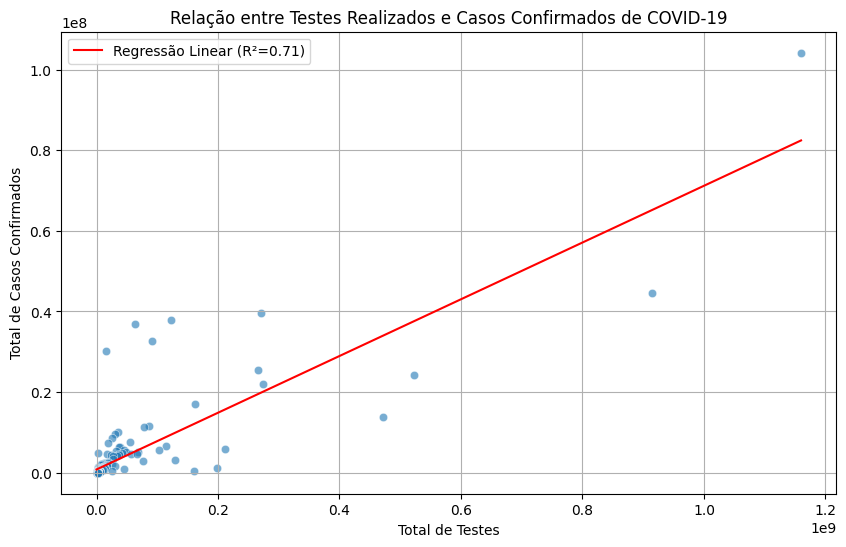

In [23]:
# Criar o gráfico de dispersão
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Total_test', y='Total_cases', alpha=0.6)

# Ajuste de uma reta de regressão
slope, intercept, r_value, p_value, std_err = linregress(df['Total_test'], df['Total_cases'])
x_vals = np.linspace(df['Total_test'].min(), df['Total_test'].max(), 100)
y_vals = slope * x_vals + intercept
plt.plot(x_vals, y_vals, color='red', label=f'Regressão Linear (R²={r_value**2:.2f})')

# Configurações do gráfico
plt.xlabel('Total de Testes')
plt.ylabel('Total de Casos Confirmados')
plt.title('Relação entre Testes Realizados e Casos Confirmados de COVID-19')
plt.legend()
plt.grid(True)

# Exibir o gráfico
plt.show()

4.	📊 Variabilidade de Casos por Região
	- Se houver agrupamento por continente ou região compare a variação dos casos.
	- 🔍 Insight: Existem continentes com mais outliers? Algum tem uma variação muito maior nos casos?

  R: **Os continentes Oceania e os dados Desconhecidos que precisaram se tratados futuramente, mostraram que tiveram maior variabilidade e os dois mostraram haver outliers em suas amostras.**


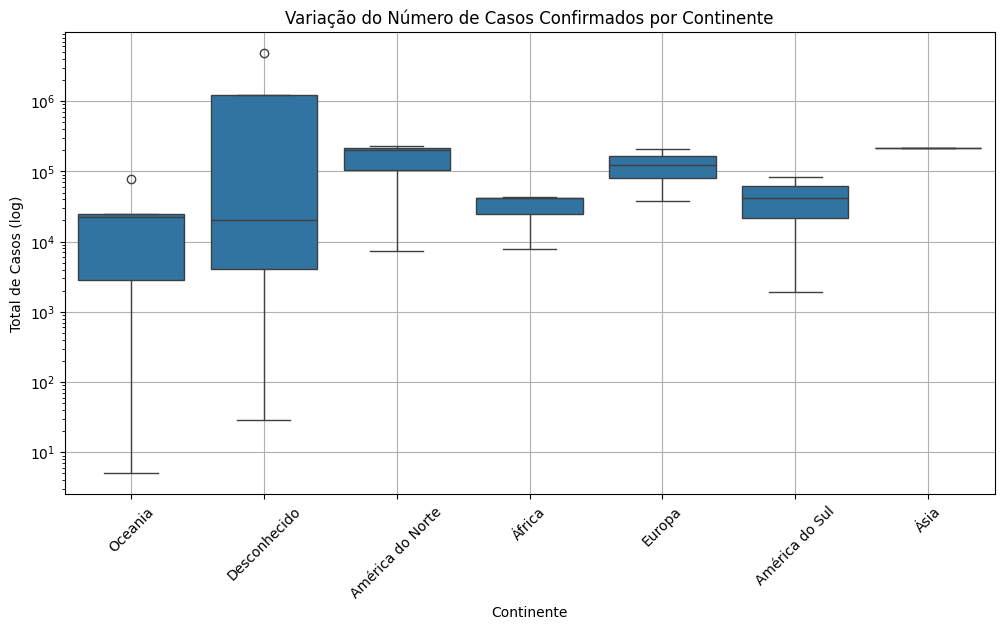

In [24]:
df_20 = df_top20_recovery[['Continent', 'Total Cases']].dropna()

# Garantindo que 'Total Cases' seja numérico
df_20['Total Cases'] = pd.to_numeric(df_20['Total Cases'], errors='coerce')

# Criando o boxplot
plt.figure(figsize=(12, 6))
# Usando o df_20 para boxplot
sns.boxplot(x='Continent', y='Total Cases', data=df_20, showfliers=True) # Changed df to df_20
plt.yscale("log")
plt.xlabel("Continente")
plt.ylabel("Total de Casos (log)")
plt.title("Variação do Número de Casos Confirmados por Continente")
plt.xticks(rotation=45)
plt.grid()

# Display the plot
plt.show()

5.	📉 Tendência de Casos Ativos por População
	- Analise se países com maior população também tiveram mais casos ativos proporcionalmente.
	- 🔍 Insight: Países populosos sempre tiveram mais casos ou a distribuição é desigual?
  
  R: **O Gráfico demonstra que a distribuição está um pouco desigual, pois o gráfico de dispersão está bem espalhado.**

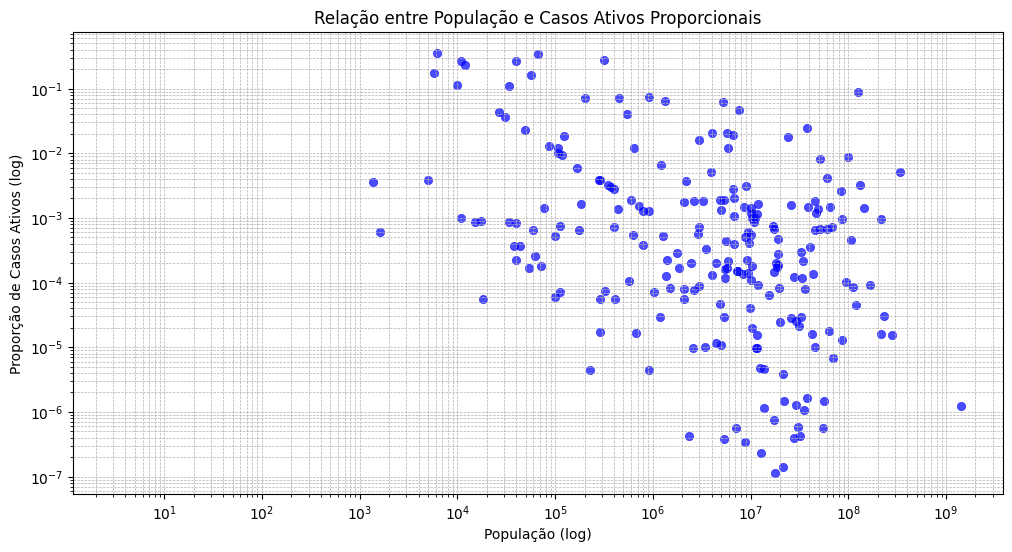

In [25]:
required_columns = ['Country', 'Population', 'Active_cases']
if not all(col in df.columns for col in required_columns):
    print("Erro: As colunas necessárias não estão no dataset.")
else:
    # Converter colunas para numérico e remover valores inválidos
    df['Population'] = pd.to_numeric(df['Population'], errors='coerce')
    df['Active_cases'] = pd.to_numeric(df['Active_cases'], errors='coerce')

    # Criar a coluna de proporção de casos ativos
    df['Active_cases_ratio'] = df['Active_cases'] / df['Population']

    # Remover valores nulos e zeros para evitar problemas na escala log
    df = df[(df['Population'] > 0) & (df['Active_cases_ratio'] > 0)].dropna()

    # Criar o gráfico de dispersão
    plt.figure(figsize=(12, 6))

    # Definir a paleta de cores por continente, se disponível
    if 'Continent' in df.columns:
        sns.scatterplot(
            x=df['Population'],
            y=df['Active_cases_ratio'],
            hue=df['Continent'],
            palette="viridis",
            alpha=0.7,
            edgecolor=None
        )
    else:
        sns.scatterplot(
            x=df['Population'],
            y=df['Active_cases_ratio'],
            color="blue",
            alpha=0.7,
            edgecolor=None
        )

    # Adicionar linha de tendência log-log
    sns.regplot(
        x=np.log10(df['Population']),
        y=np.log10(df['Active_cases_ratio']),
        scatter=False,
        line_kws={"color": "red", "lw": 2}
    )

    # Ajustar escalas logarítmicas
    plt.xscale("log")
    plt.yscale("log")

    # Labels
    plt.xlabel("População (log)")
    plt.ylabel("Proporção de Casos Ativos (log)")
    plt.title("Relação entre População e Casos Ativos Proporcionais")
    plt.grid(True, which="both", linestyle="--", linewidth=0.5)

    # Exibir gráfico
    plt.show()

1. **Distribuição de Casos e Mortes**: Há países com muitos casos, mas poucas mortes?
2. **Relação Entre Casos e Mortes**: Existe uma correlação entre casos e mortes?
3. **Casos Ativos vs. População**: Países mais populosos possuem mais casos ativos?
4. **Países com Mais Casos e Mortes**:Quais países lideram em número de casos e mortes?
5. **Proporção de Recuperação**: A taxa de recuperação é homogênea entre os países?
6. **Testagem vs. População**: Países mais populosos realizam mais testes?
7. **Correlações**: Quais variáveis apresentam maior correlação?

1. **Distribuição de Casos e Mortes**: Há países com muitos casos, mas poucas mortes?

R: Existem alguns países com muitos casos e poucas mortes de acordo com o gráfico

In [26]:
df

,Serial_number,Country,Total_cases,Total_deaths,Total_recovered,Active_cases,Total_test,Population,Mortality_rate,Recovery_rate,CODE,Active_cases_ratio
0,1,USA,104196861.0,1132935.0,101322779.0,1741147.0,1.159833e+09,3.348053e+08,1.087302,9.724168e+01,USA,0.005200
1,2,India,44682784.0,530740.0,44150289.0,1755.0,9.152658e+08,1.406632e+09,1.187795,9.880828e+01,IND,0.000001
2,3,France,39524311.0,164233.0,39264546.0,95532.0,2.714902e+08,6.558452e+07,0.415524,9.934277e+01,FRA,0.001457
3,4,Germany,37779833.0,165711.0,37398100.0,216022.0,1.223324e+08,8.388360e+07,0.438623,9.898959e+01,DEU,0.002575
4,5,Brazil,36824580.0,697074.0,35919372.0,208134.0,6.377617e+07,2.153536e+08,1.892958,9.754184e+01,BRA,0.000966
...,...,...,...,...,...,...,...,...,...,...,...,...
221,222,Tuvalu,2805.0,2179.0,235145.5,2805.0,2.216193e+06,1.206600e+04,77.682709,8.383084e+03,TUV,0.232471
222,223,Saint Helena,2166.0,2179.0,2.0,2164.0,2.216193e+06,6.115000e+03,100.600185,9.233610e-02,Saint Helena,0.353884
224,225,Montserrat,1403.0,8.0,1376.0,19.0,1.776200e+04,4.965000e+03,0.570207,9.807555e+01,MSR,0.003827
225,226,Niue,747.0,2179.0,746.0,1.0,2.216193e+06,1.622000e+03,291.700134,9.986613e+01,NIU,0.000617


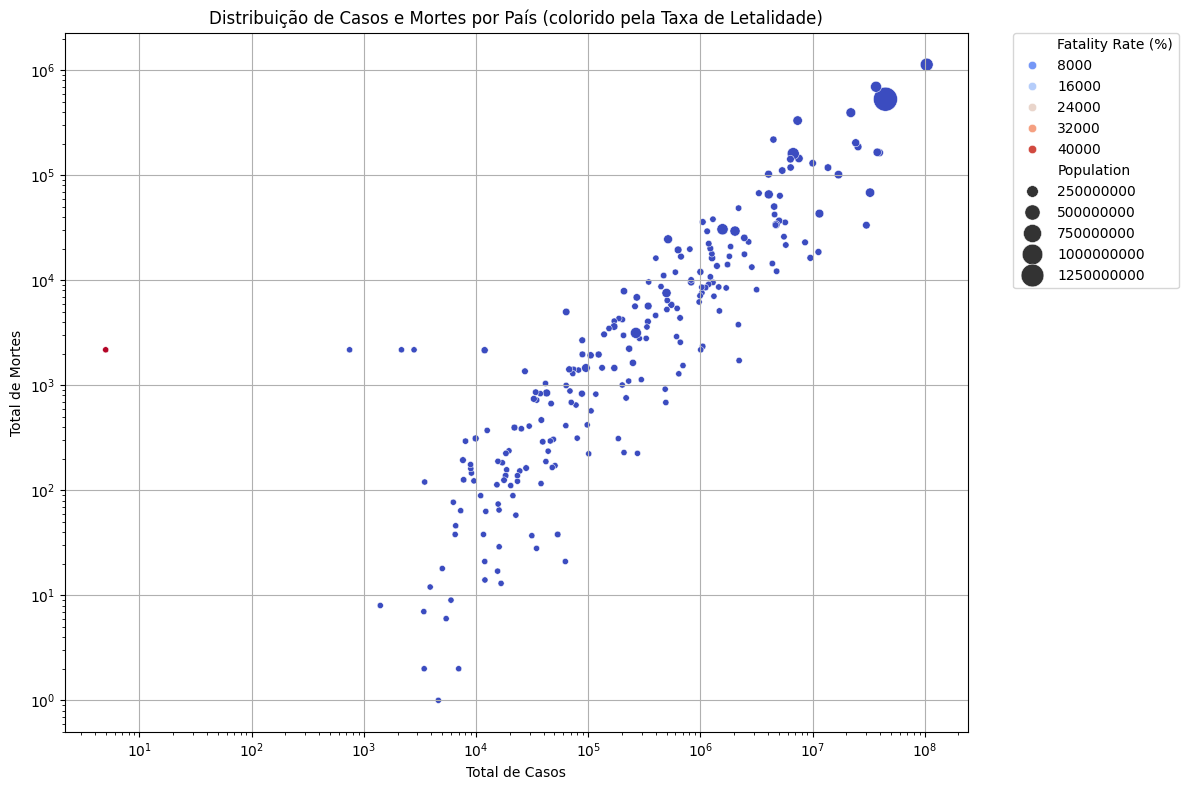

In [27]:
# Calcula a taxa de letalidade (%)
df['Fatality Rate (%)'] = (df['Total_deaths'] / df['Total_cases']) * 100

# Visualização: Casos vs Mortes, colorido pela taxa de letalidade
plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(
    data=df,
    x='Total_cases',
    y='Total_deaths',
    hue='Fatality Rate (%)',
    palette='coolwarm',
    size='Population',
    sizes=(20, 300),
    legend='brief'
)

plt.title('Distribuição de Casos e Mortes por País (colorido pela Taxa de Letalidade)')
plt.xlabel('Total de Casos')
plt.ylabel('Total de Mortes')
plt.xscale('log')
plt.yscale('log')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.grid(True)
plt.tight_layout()
plt.show()

2. **Relação Entre Casos e Mortes**: Existe uma correlação entre casos e mortes?

R: O Coeficiente de Correlação deu 0.88, quanto mais próximo de 1 mais correlação existe, então nesse caso existem correlação no casos e mortes


Coeficiente de Correlação de Pearson: 0.8789
Valor p (significância): 0.0000


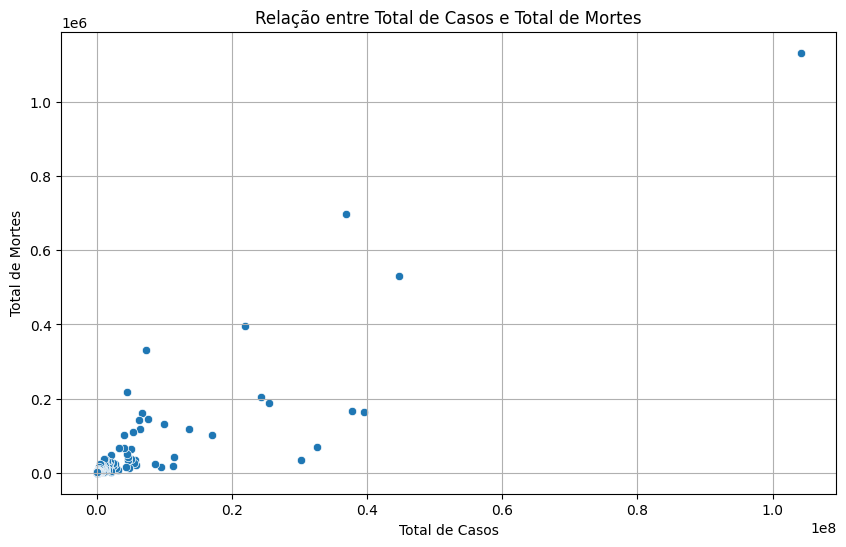

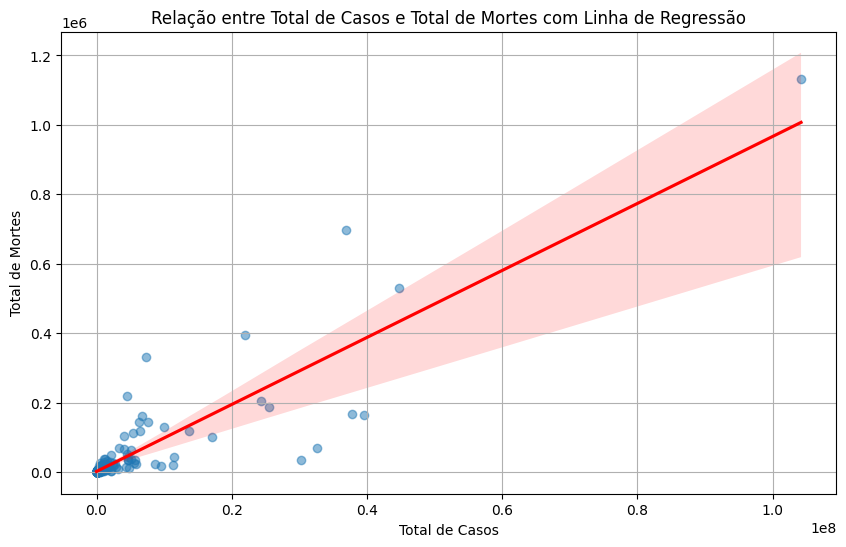

In [28]:
# Calculando o coeficiente de correlação de Pearson
corr, p_value = pearsonr(df['Total_cases'], df['Total_deaths'])
print(f"\nCoeficiente de Correlação de Pearson: {corr:.4f}")
print(f"Valor p (significância): {p_value:.4f}")
# Interpretação: correlação próxima de 1 ou -1 indica forte relação; p < 0.05 sugere significância estatística

# Visualizando a relação com um gráfico de dispersão
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Total_cases', y='Total_deaths', data=df)
plt.title('Relação entre Total de Casos e Total de Mortes')
plt.xlabel('Total de Casos')
plt.ylabel('Total de Mortes')
plt.grid(True)
plt.show()

# Adicionando uma linha de regressão para melhor visualização
plt.figure(figsize=(10, 6))
sns.regplot(x='Total_cases', y='Total_deaths', data=df, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Relação entre Total de Casos e Total de Mortes com Linha de Regressão')
plt.xlabel('Total de Casos')
plt.ylabel('Total de Mortes')
plt.grid(True)
plt.show()

3. **Casos Ativos vs. População**: Países mais populosos possuem mais casos ativos?

R: O Coeficiente de Correlação deu 0.10, quanto mais próximo de 0 menor será a correlação, então nesse caso, há uma baixa correlação de fatores


Coeficiente de Correlação de Pearson: 0.1039
Valor p (significância): 0.1220


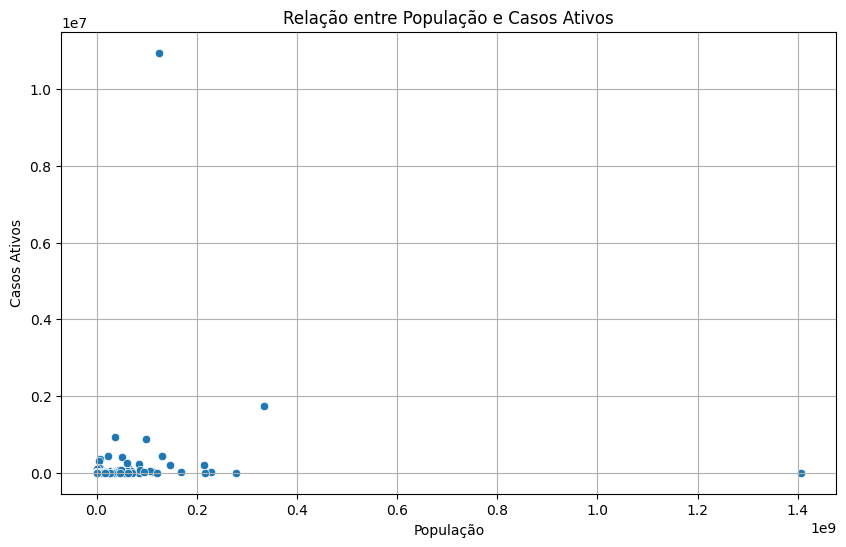

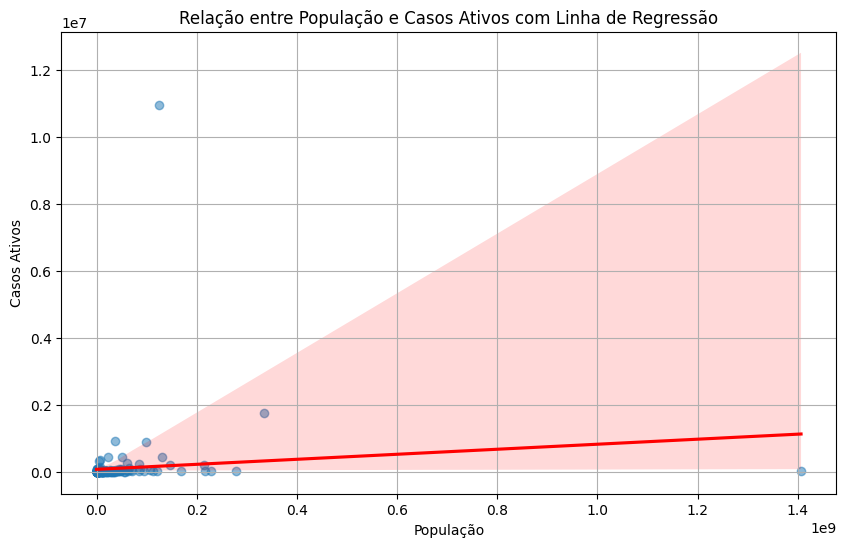


Países com maior população e seus casos ativos:
       Country    Population  Active_cases
1        India  1.406632e+09        1755.0
0          USA  3.348053e+08     1741147.0
19   Indonesia  2.791345e+08        4264.0
52    Pakistan  2.294890e+08        6984.0
107    Nigeria  2.167469e+08        3458.0


In [29]:
# Calculando o coeficiente de correlação de Pearson
corr, p_value = pearsonr(df['Population'], df['Active_cases'])
print(f"\nCoeficiente de Correlação de Pearson: {corr:.4f}")
print(f"Valor p (significância): {p_value:.4f}")
# Interpretação: correlação próxima de 1 indica que população maior está associada a mais casos ativos; p < 0.05 sugere significância

# Visualizando a relação com um gráfico de dispersão
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Population', y='Active_cases', data=df)
plt.title('Relação entre População e Casos Ativos')
plt.xlabel('População')
plt.ylabel('Casos Ativos')
plt.grid(True)
plt.show()

# Gráfico com linha de regressão para observar a tendência
plt.figure(figsize=(10, 6))
sns.regplot(x='Population', y='Active_cases', data=df, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Relação entre População e Casos Ativos com Linha de Regressão')
plt.xlabel('População')
plt.ylabel('Casos Ativos')
plt.grid(True)
plt.show()

# Identificando países com maior população e casos ativos
print("\nPaíses com maior população e seus casos ativos:")
top_population = df.nlargest(5, 'Population')[['Country', 'Population', 'Active_cases']]
print(top_population)

4. **Países com Mais Casos e Mortes**:Quais países lideram em número de casos e mortes?

R: Países com mais casos:

   Country  Total_cases

0      USA  104196861.0

1    India   44682784.0

2   France   39524311.0

3  Germany   37779833.0

4   Brazil   36824580.0




Países com mais mortes:

   Country  Total_deaths

0      USA     1132935.0

4   Brazil      697074.0

1    India      530740.0

9   Russia      395108.0

18  Mexico      332198.0



Países com mais casos:
   Country  Total_cases
0      USA  104196861.0
1    India   44682784.0
2   France   39524311.0
3  Germany   37779833.0
4   Brazil   36824580.0

Países com mais mortes:
   Country  Total_deaths
0      USA     1132935.0
4   Brazil      697074.0
1    India      530740.0
9   Russia      395108.0
18  Mexico      332198.0


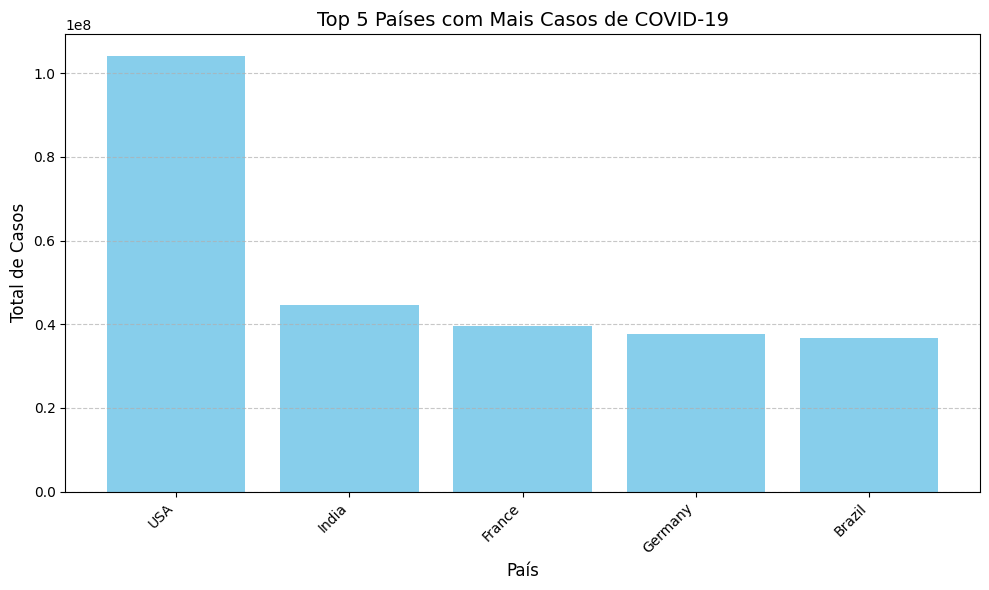

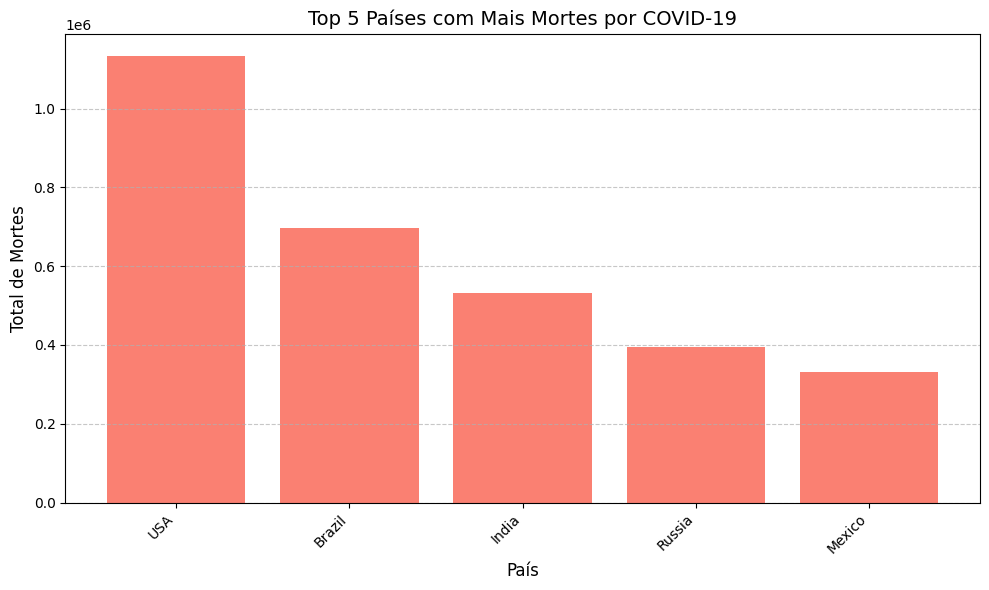

In [30]:
# Identificando os 5 países com mais casos
top_cases = df.nlargest(5, 'Total_cases')[['Country', 'Total_cases']]
print("\nPaíses com mais casos:")
print(top_cases)

# Identificando os 5 países com mais mortes
top_deaths = df.nlargest(5, 'Total_deaths')[['Country', 'Total_deaths']]
print("\nPaíses com mais mortes:")
print(top_deaths)

# Gráfico de barras para os países com mais casos
plt.figure(figsize=(10, 6))
plt.bar(top_cases['Country'], top_cases['Total_cases'], color='skyblue')
plt.title('Top 5 Países com Mais Casos de COVID-19', fontsize=14)
plt.xlabel('País', fontsize=12)
plt.ylabel('Total de Casos', fontsize=12)
plt.xticks(rotation=45, ha='right')  # Rotaciona os nomes dos países para melhor leitura
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Gráfico de barras para os países com mais mortes
plt.figure(figsize=(10, 6))
plt.bar(top_deaths['Country'], top_deaths['Total_deaths'], color='salmon')
plt.title('Top 5 Países com Mais Mortes por COVID-19', fontsize=14)
plt.xlabel('País', fontsize=12)
plt.ylabel('Total de Mortes', fontsize=12)
plt.xticks(rotation=45, ha='right')  # Rotaciona os nomes dos países
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

5. **Proporção de Recuperação**: A taxa de recuperação é homogênea entre os países?

R: a média é de 0.9 e o std "Desvio padrão" foi de 0,20 estando acima do esperando para uma homogeneidade, nesse caso a curva se comporta mais para heterogeneidade


Estatísticas da Taxa de Recuperação:
count    206.000000
mean       0.907954
std        0.201026
min        0.000923
25%        0.962389
50%        0.980886
75%        0.990449
max        0.998661
Name: Recovery_rate, dtype: float64

Países com maiores taxas de recuperação:
      Country  Recovery_rate
225      Niue       0.998661
213     Palau       0.998329
149   Burundi       0.998168
92      Qatar       0.998073
71   Mongolia       0.997804

Países com menores taxas de recuperação:
           Country  Recovery_rate
222   Saint Helena       0.000923
10          Turkey       0.013797
186          Samoa       0.099770
193   Saint Martin       0.114363
131  French Guiana       0.114804


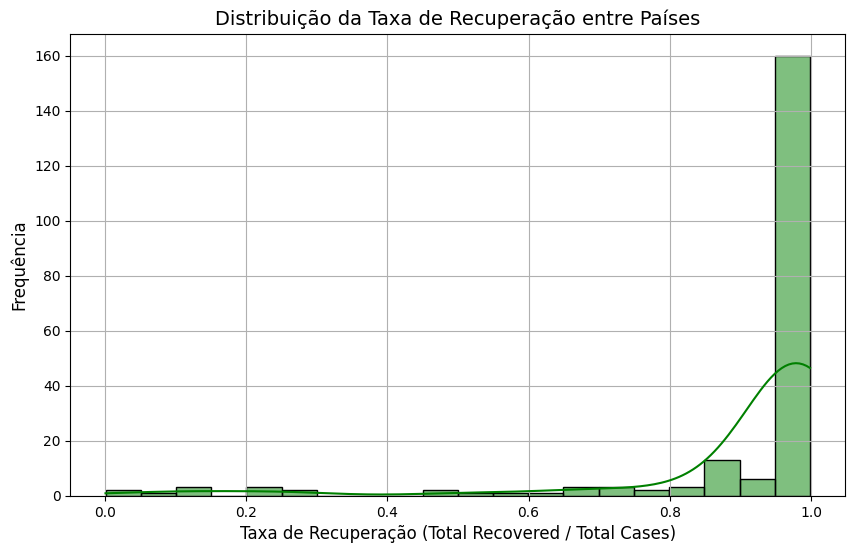

In [31]:
# Calculando a taxa de recuperação (Total Recovered / Total Cases)
df['Recovery_rate'] = df['Total_recovered'] / df['Total_cases']

# Removendo possíveis taxas inválidas (ex.: > 1 ou NaN)
df = df[(df['Recovery_rate'] <= 1) & (df['Recovery_rate'].notna())]

# Estatísticas descritivas da taxa de recuperação
print("\nEstatísticas da Taxa de Recuperação:")
print(df['Recovery_rate'].describe())

# Identificando países com as maiores e menores taxas de recuperação
print("\nPaíses com maiores taxas de recuperação:")
print(df.nlargest(5, 'Recovery_rate')[['Country', 'Recovery_rate']])
print("\nPaíses com menores taxas de recuperação:")
print(df.nsmallest(5, 'Recovery_rate')[['Country', 'Recovery_rate']])

# Gráfico de distribuição da taxa de recuperação (histograma)
plt.figure(figsize=(10, 6))
sns.histplot(df['Recovery_rate'], bins=20, kde=True, color='green')
plt.title('Distribuição da Taxa de Recuperação entre Países', fontsize=14)
plt.xlabel('Taxa de Recuperação (Total Recovered / Total Cases)', fontsize=12)
plt.ylabel('Frequência', fontsize=12)
plt.grid(True)
plt.show()

6. **Testagem vs. População**: Países mais populosos realizam mais testes?

R: Existem uma correlação de 0,62 moderada, aonde os 20 países mais populosos realizam testes e outros não

In [32]:
df

,Serial_number,Country,Total_cases,Total_deaths,Total_recovered,Active_cases,Total_test,Population,Mortality_rate,Recovery_rate,CODE,Active_cases_ratio,Fatality Rate (%)
0,1,USA,104196861.0,1132935.0,101322779.0,1741147.0,1.159833e+09,3.348053e+08,1.087302,0.972417,USA,0.005200,1.087302
1,2,India,44682784.0,530740.0,44150289.0,1755.0,9.152658e+08,1.406632e+09,1.187795,0.988083,IND,0.000001,1.187795
2,3,France,39524311.0,164233.0,39264546.0,95532.0,2.714902e+08,6.558452e+07,0.415524,0.993428,FRA,0.001457,0.415524
3,4,Germany,37779833.0,165711.0,37398100.0,216022.0,1.223324e+08,8.388360e+07,0.438623,0.989896,DEU,0.002575,0.438623
4,5,Brazil,36824580.0,697074.0,35919372.0,208134.0,6.377617e+07,2.153536e+08,1.892958,0.975418,BRA,0.000966,1.892958
...,...,...,...,...,...,...,...,...,...,...,...,...,...
219,220,Saint Pierre Miquelon,3452.0,2.0,2449.0,1001.0,2.540000e+04,5.759000e+03,0.057937,0.709444,Saint Pierre Miquelon,0.173815,0.057937
220,221,Wallis and Futuna,3427.0,7.0,438.0,2982.0,2.050800e+04,1.098200e+04,0.204260,0.127809,WLF,0.271535,0.204260
222,223,Saint Helena,2166.0,2179.0,2.0,2164.0,2.216193e+06,6.115000e+03,100.600185,0.000923,Saint Helena,0.353884,100.600185
224,225,Montserrat,1403.0,8.0,1376.0,19.0,1.776200e+04,4.965000e+03,0.570207,0.980756,MSR,0.003827,0.570207


20 países mais populosos do dataset:
         Country    Population    Total_test
1          India  1.406632e+09  9.152658e+08
0            USA  3.348053e+08  1.159833e+09
19     Indonesia  2.791345e+08  1.141589e+08
52      Pakistan  2.294890e+08  3.057086e+07
107      Nigeria  2.167469e+08  5.708974e+06
4         Brazil  2.153536e+08  6.377617e+07
47    Bangladesh  1.678857e+08  1.524701e+07
9         Russia  1.458059e+08  2.734000e+08
18        Mexico  1.315628e+08  1.935620e+07
5          Japan  1.255848e+08  9.214464e+07
91      Ethiopia  1.208127e+08  5.459809e+06
36   Philippines  1.125090e+08  3.434333e+07
88         Egypt  1.061567e+08  3.693367e+06
12       Vietnam  9.895354e+07  8.582655e+07
132          DRC  9.524079e+07  8.467040e+05
17          Iran  8.602284e+07  5.442078e+07
10        Turkey  8.556198e+07  1.627434e+08
3        Germany  8.388360e+07  1.223324e+08
30      Thailand  7.007820e+07  1.727078e+07
8             UK  6.849791e+07  5.225265e+08

Valores ausentes 

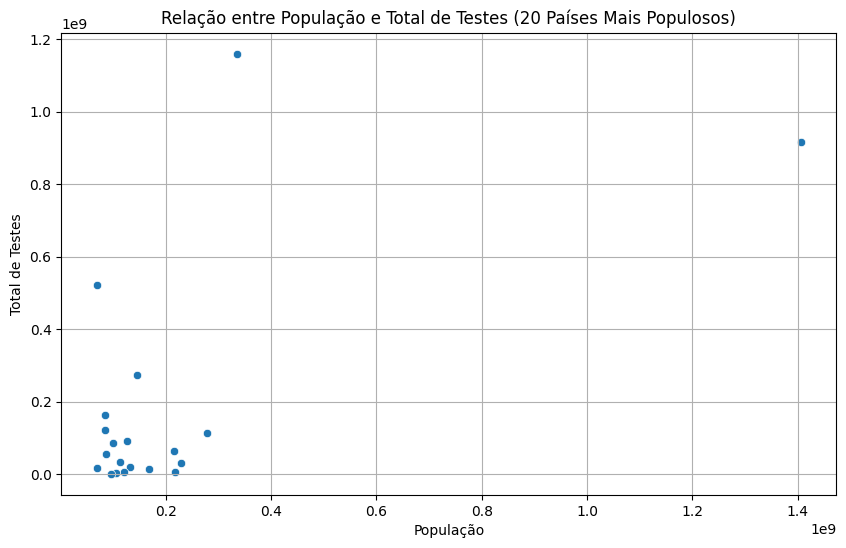

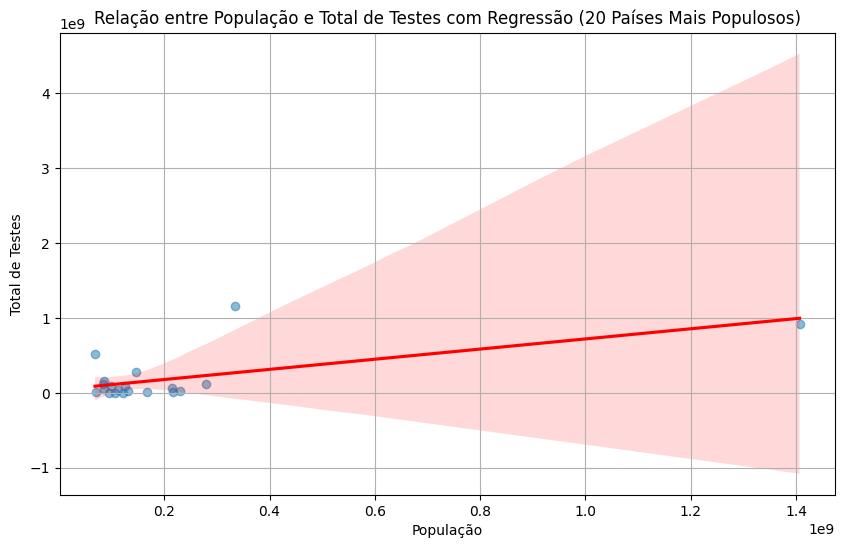


Dados dos 20 países mais populosos analisados:
         Country    Population    Total_test
1          India  1.406632e+09  9.152658e+08
0            USA  3.348053e+08  1.159833e+09
19     Indonesia  2.791345e+08  1.141589e+08
52      Pakistan  2.294890e+08  3.057086e+07
107      Nigeria  2.167469e+08  5.708974e+06
4         Brazil  2.153536e+08  6.377617e+07
47    Bangladesh  1.678857e+08  1.524701e+07
9         Russia  1.458059e+08  2.734000e+08
18        Mexico  1.315628e+08  1.935620e+07
5          Japan  1.255848e+08  9.214464e+07
91      Ethiopia  1.208127e+08  5.459809e+06
36   Philippines  1.125090e+08  3.434333e+07
88         Egypt  1.061567e+08  3.693367e+06
12       Vietnam  9.895354e+07  8.582655e+07
132          DRC  9.524079e+07  8.467040e+05
17          Iran  8.602284e+07  5.442078e+07
10        Turkey  8.556198e+07  1.627434e+08
3        Germany  8.388360e+07  1.223324e+08
30      Thailand  7.007820e+07  1.727078e+07
8             UK  6.849791e+07  5.225265e+08


In [33]:
# Ordenando o DataFrame por população em ordem decrescente
df_sorted = df.sort_values(by='Population', ascending=False)

# Selecionando os 20 primeiros países (os mais populosos)
df_top20 = df_sorted.head(20)

# Exibindo os 20 países mais populosos para verificar
print("20 países mais populosos do dataset:")
print(df_top20[['Country', 'Population', 'Total_test']])

# Verificando valores ausentes nas colunas de interesse
print("\nValores ausentes em 'Total Test':", df_top20['Total_test'].isnull().sum())
print("Valores ausentes em 'Population':", df_top20['Population'].isnull().sum())

# Removendo linhas com valores ausentes nas colunas analisadas
df_clean = df_top20.dropna(subset=['Total_test', 'Population'])

# Calculando o coeficiente de correlação de Pearson
corr, p_value = pearsonr(df_clean['Population'], df_clean['Total_test'])
print(f"\nCoeficiente de Correlação de Pearson (20 países mais populosos): {corr:.4f}")
print(f"Valor p (significância): {p_value:.4f}")

# Visualizando a relação com um gráfico de dispersão
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Population', y='Total_test', data=df_clean)
plt.title('Relação entre População e Total de Testes (20 Países Mais Populosos)')
plt.xlabel('População')
plt.ylabel('Total de Testes')
plt.grid(True)
plt.show()

# Gráfico com linha de regressão
plt.figure(figsize=(10, 6))
sns.regplot(x='Population', y='Total_test', data=df_clean, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Relação entre População e Total de Testes com Regressão (20 Países Mais Populosos)')
plt.xlabel('População')
plt.ylabel('Total de Testes')
plt.grid(True)
plt.show()

# Exibindo os dados finais dos 20 países mais populosos analisados
print("\nDados dos 20 países mais populosos analisados:")
print(df_clean[['Country', 'Population', 'Total_test']])

7. **Correlações**: Quais variáveis apresentam maior correlação?

R: Abaixo as variaveis com maiores correlação entre si


Pares de variáveis com maior correlação (em valor absoluto):

               Var1               Var2  Correlation

87   Mortality_rate      |  Fatality Rate (%)       |          1.000000

14      Total_cases     |   Total_recovered          |       0.990353

25     Total_deaths     |   Total_recovered  |               0.883442

13      Total_cases    |     Total_deaths         |        0.878055

38  Total_recovered       |    Total_test        |         0.843942



Matriz de Correlação (Pearson):
                    Serial_number  Total_cases  Total_deaths  Total_recovered  \
Serial_number            1.000000    -0.463275     -0.410770        -0.449786   
Total_cases             -0.463275     1.000000      0.878055         0.990353   
Total_deaths            -0.410770     0.878055      1.000000         0.883442   
Total_recovered         -0.449786     0.990353      0.883442         1.000000   
Active_cases            -0.173483     0.345160      0.159819         0.277255   
Total_test              -0.384008     0.840532      0.792478         0.843942   
Population              -0.290591     0.524702      0.574768         0.526626   
Mortality_rate           0.163407    -0.033891     -0.020345        -0.032733   
Recovery_rate           -0.186192     0.041771      0.054251         0.090175   
Active_cases_ratio       0.214300    -0.039960     -0.059983        -0.046737   
Fatality Rate (%)        0.163407    -0.033891     -0.020345        -0.03273

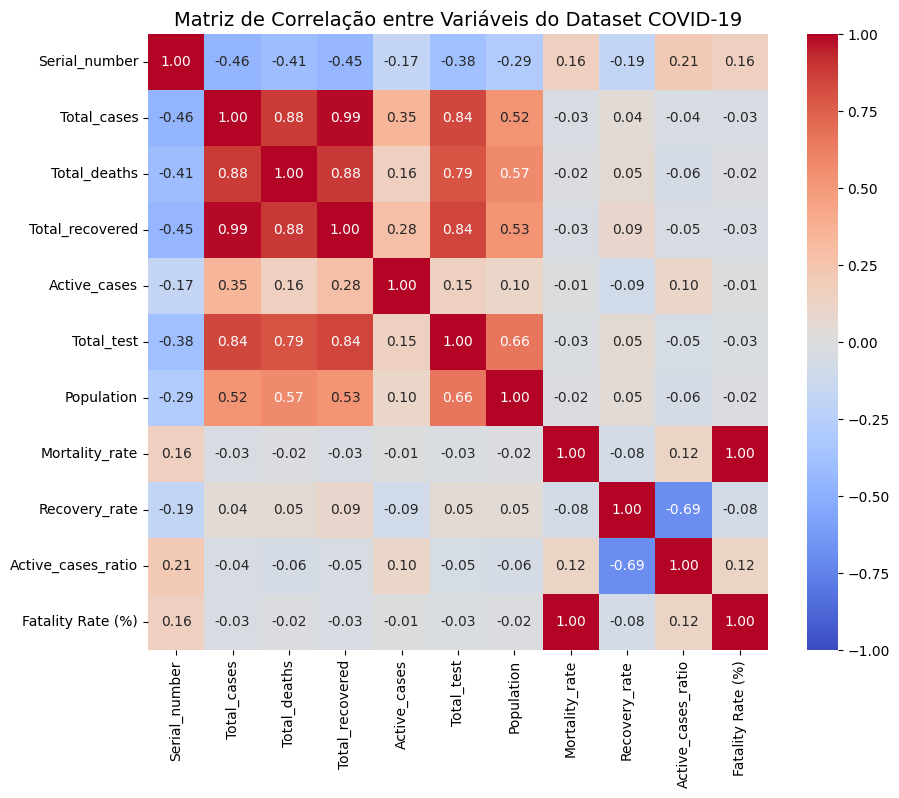

In [34]:
# Selecionando apenas colunas numericas antes de calcular a correlação
numerical_df = df.select_dtypes(include=np.number)

# Calculando a matriz de correlação
correlation_matrix = numerical_df.corr(method='pearson')

# Exibindo a matriz de correlação
print("\nMatriz de Correlação (Pearson):")
print(correlation_matrix)

# Identificando as maiores correlações (excluindo a diagonal, que é sempre 1)
# Transformando a matriz em um formato "longo" para análise
corr_pairs = correlation_matrix.stack().reset_index()
corr_pairs.columns = ['Var1', 'Var2', 'Correlation']
# Removendo pares iguais (ex.: Total Cases vs. Total Cases) e duplicatas
corr_pairs = corr_pairs[corr_pairs['Var1'] != corr_pairs['Var2']]
corr_pairs = corr_pairs.drop_duplicates(subset=['Correlation'])
# Ordenando por valor absoluto da correlação
corr_pairs['Abs_Correlation'] = corr_pairs['Correlation'].abs()
top_correlations = corr_pairs.nlargest(5, 'Abs_Correlation')
print("\nPares de variáveis com maior correlação (em valor absoluto):")
print(top_correlations[['Var1', 'Var2', 'Correlation']])

# Visualizando a matriz de correlação com um heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0, fmt='.2f')
plt.title('Matriz de Correlação entre Variáveis do Dataset COVID-19', fontsize=14)
plt.show()